In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sys

In [2]:
df1 = pd.read_csv("Sallah Call Center Data Base - Feb.csv")
df2 = pd.read_csv("Sallah Call Center Data Base - Mar .csv")
df3 = pd.read_csv("Sallah Call Center Data Base -Apr.csv")

In [3]:
df = pd.concat([df1, df2, df3], ignore_index=True)

In [ ]:
df

,Project,Date,Month,Forecasted Calls,Calls Offered,Calls Handled,Calls Handled With in Thrshold,Calls Abandon,ASA,Answer Time,Agent Name
0,Project A,2/1/2022,22-Feb,13473,8393,8381,8380,12,1.689178,14157,Ali
1,Project A,2/2/2022,22-Feb,13255,5144,5134,5096,10,2.337164,11999,Samir
2,Project A,2/3/2022,22-Feb,13209,8450,8436,8432,14,1.874822,15816,Rania
3,Project A,2/4/2022,22-Feb,13002,10883,10614,7376,269,51.207744,543519,Rania
4,Project A,2/5/2022,22-Feb,12758,11445,11393,11027,52,7.235232,82431,Ahmed
...,...,...,...,...,...,...,...,...,...,...,...
262,Project C,4/26/2022,Apr-22,294,164,163,163,1,1.883436,307,Nour
263,Project C,4/27/2022,Apr-22,291,166,158,145,8,8.411392,1329,Hassan
264,Project C,4/28/2022,Apr-22,288,149,142,130,7,7.429577,1055,Tariq
265,Project C,4/29/2022,Apr-22,219,137,136,132,1,4.426471,602,Khaled


In [4]:
df.describe()

,Forecasted Calls,Calls Offered,Calls Handled,Calls Handled With in Thrshold,Calls Abandon,ASA,Answer Time
count,267.000000,267.000000,267.000000,267.000000,267.000000,267.000000,2.670000e+02
mean,9127.606742,6535.149813,6448.846442,5950.876404,86.303371,9.220929,9.224000e+04
std,5926.564904,5255.978390,5118.075138,4571.721375,287.741271,19.585007,2.883870e+05
min,213.000000,81.000000,79.000000,75.000000,0.000000,1.578571,1.720000e+02
25%,2674.000000,1834.500000,1824.500000,1804.000000,5.000000,1.875656,5.325500e+03
50%,12477.000000,6601.000000,6592.000000,6291.000000,12.000000,2.743916,1.337400e+04
75%,13208.000000,8885.000000,8809.000000,8153.500000,42.000000,6.748759,3.149700e+04
max,17685.000000,30381.000000,29630.000000,22741.000000,3101.000000,180.903391,2.688948e+06


In [5]:
df.describe(include=object)

,Project,Date,Month,Agent Name
count,267,267,267,267
unique,3,89,3,16
top,Project A,2/1/2022,Mar-22,Huda
freq,89,3,93,25


In [6]:
df.isnull().sum()

Project                           0
Date                              0
Month                             0
Forecasted Calls                  0
Calls Offered                     0
Calls Handled                     0
Calls Handled With in Thrshold    0
Calls Abandon                     0
ASA                               0
Answer Time                       0
Agent Name                        0
dtype: int64

In [50]:
for i in df.select_dtypes(include="object").columns:
    print(df[i].value_counts())
    print("--------------------------------------------------------------")

Project
Project A    89
Project B    89
Project C    89
Name: count, dtype: int64
--------------------------------------------------------------
Date
2/1/2022     3
2/2/2022     3
2/3/2022     3
2/4/2022     3
2/5/2022     3
            ..
4/26/2022    3
4/27/2022    3
4/28/2022    3
4/29/2022    3
4/30/2022    3
Name: count, Length: 89, dtype: int64
--------------------------------------------------------------
Month
Mar-22    93
Apr-22    90
22-Feb    84
Name: count, dtype: int64
--------------------------------------------------------------
Agent Name
Huda       25
Ali        23
Rania      21
Samir      20
Khaled     20
Tariq      20
Dina       19
Omar       19
Ahmed      15
Mona       15
Fatma      14
Youssef    13
Sara       11
Nour       11
Laila      11
Hassan     10
Name: count, dtype: int64
--------------------------------------------------------------


In [51]:
df.columns

Index(['Project', 'Date', 'Month', 'Forecasted Calls', 'Calls Offered',
       'Calls Handled', 'Calls Handled With in Thrshold', 'Calls Abandon',
       'ASA', 'Answer Time', 'Agent Name'],
      dtype='object')

In [59]:
callinmon = df.groupby("Month")["Calls Offered"].sum()
round(df.groupby("Month")["Calls Offered"].sum() / df["Calls Offered"].sum(), 2)* 100

Month
22-Feb    26.0
Apr-22    24.0
Mar-22    50.0
Name: Calls Offered, dtype: float64

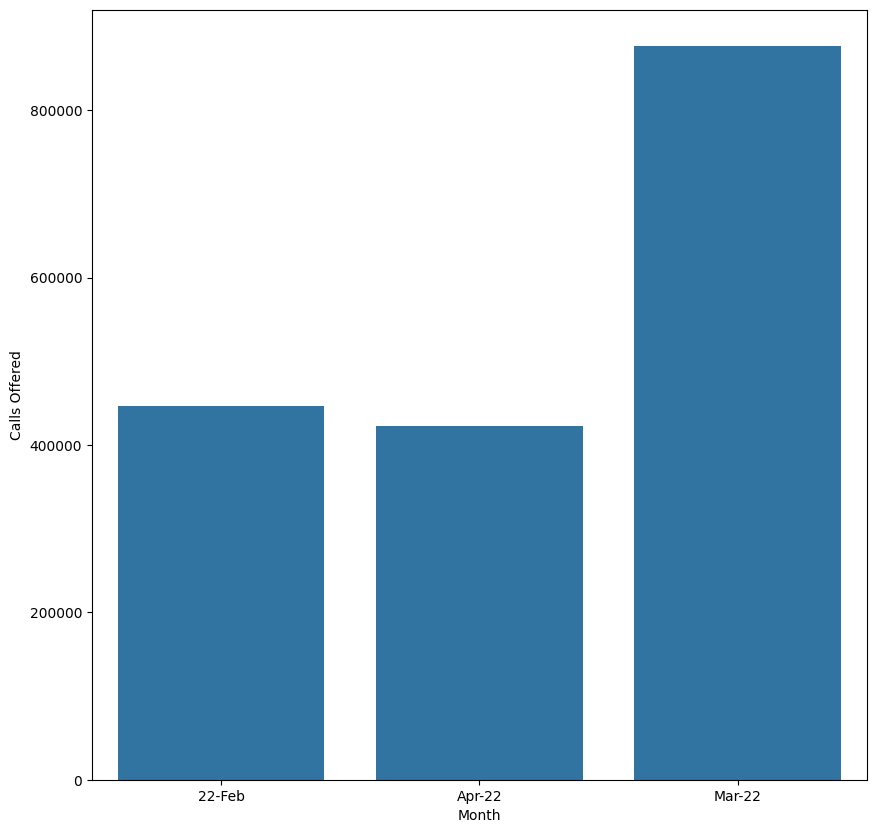

In [60]:
plt.figure(figsize=(10, 10))
sys.barplot(callinmon)
plt.show()

In [73]:
result = df.groupby("Agent Name")[["Calls Handled", "Calls Offered"]].sum()

result["ratio"] = (result["Calls Handled"] / result["Calls Offered"]).round(2)

result = result.sort_values("ratio", ascending=False)

In [74]:
result

,Calls Handled,Calls Offered,ratio
Agent Name,,,
Ali,148844,149585,1.00
Laila,54180,54365,1.00
Samir,141668,142212,1.00
Sara,73427,73718,1.00
Khaled,121234,121955,0.99
Mona,120095,120779,0.99
Hassan,59649,60045,0.99
Ahmed,74962,75365,0.99
Tariq,157377,159080,0.99


In [8]:
df.to_csv("Salla_data.csv")